# Video Game Sales — Full Pipeline

**Dataset:** Video Game Sales (`vgsales.csv`)  
**Source:** https://www.kaggle.com/datasets/gregorut/videogamesales

### About the Dataset
This dataset was scraped from VGChartz and contains sales records for video games that sold more than 100,000 copies. Each row represents a single game on a specific platform and includes the game title, platform, release year, genre, publisher, and sales figures broken down by region (North America, Europe, Japan, and Other), plus a global total (in millions of units).

### Analysis Intent
- Which **platforms and genres** generate the most global sales?
- How do **regional preferences** differ between NA, EU, and JP markets?
- What does the **sales trend over time** look like across the industry?
- Which **publishers** dominate by title count vs. by total sales?

### Pipeline Stages
1. Load raw data
2. Clean / ETL
3. Save cleaned CSV + SQLite DB
4. SQL queryability demonstration
5. EDA (inline figures)
6. Baseline Linear Regression
7. Improved Random Forest (no leakage)
8. Export predictions → `model_predictions.csv`

In [31]:
import os
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RAW_PATH = 'vgsales.csv'
CLEANED_PATH = 'vgsales_cleaned.csv'
DB_PATH = 'vgsales.db'
PRED_PATH = 'model_predictions.csv'

---
## Stage 1: Load Raw Data

**Reproducible download steps (Kaggle CLI):**
```bash
pip install kaggle
kaggle datasets download -d gregorut/videogamesales
unzip videogamesales.zip
```
The file `vgsales.csv` is used as-is (raw, unmodified).

In [32]:
df_raw = pd.read_csv(RAW_PATH)
print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Shape: 16,598 rows × 11 columns


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [33]:
df_raw.dtypes

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [34]:
df_raw.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


---
## Stage 2: ETL / Cleaning

All cleaning is done on a **copy** of the raw data. `df_raw` remains untouched throughout.

### 2a. Missing Values

In [35]:
df = df_raw.copy()

missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

Missing values per column:
Year         271
Publisher     58
dtype: int64


**Decision:**
- `Year` — rows with missing Year are **dropped**. A release year cannot be meaningfully imputed and is essential for time-series analysis.
- `Publisher` — filled with `'Unknown'`. The game record is still valid for sales and genre analysis even without a publisher name.

In [36]:
year_missing = df['Year'].isna().sum()
pub_missing  = df['Publisher'].isna().sum()

df = df.dropna(subset=['Year'])
df['Publisher'] = df['Publisher'].fillna('Unknown')

print(f'Dropped {year_missing} rows with missing Year')
print(f'Filled  {pub_missing} missing Publisher values -> "Unknown"')

Dropped 271 rows with missing Year
Filled  58 missing Publisher values -> "Unknown"


### 2b. Data Types

In [37]:
# Year was float due to NaNs — convert to nullable integer
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64')

# Enforce float on all sales columns
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
df[sales_cols] = df[sales_cols].apply(pd.to_numeric, errors='coerce')

print('Updated dtypes:')
print(df.dtypes)

Updated dtypes:
Rank              int64
Name                str
Platform            str
Year              Int64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


### 2c. Duplicates

In [38]:
dupes = df.duplicated(subset=['Name', 'Platform', 'Year']).sum()
df = df.drop_duplicates(subset=['Name', 'Platform', 'Year'])
print(f'Removed {dupes} duplicate rows (same Name + Platform + Year)')

Removed 1 duplicate rows (same Name + Platform + Year)


### 2d. Inconsistent Formats

In [39]:
df['Name'] = df['Name'].str.strip()
df['Platform'] = df['Platform'].str.strip().str.upper()
df['Genre'] = df['Genre'].str.strip().str.title()
df['Publisher'] = df['Publisher'].str.strip()

print('Sample after normalisation:')
df[['Name', 'Platform', 'Genre', 'Publisher']].head()

Sample after normalisation:


,Name,Platform,Genre,Publisher
0,Wii Sports,WII,Sports,Nintendo
1,Super Mario Bros.,NES,Platform,Nintendo
2,Mario Kart Wii,WII,Racing,Nintendo
3,Wii Sports Resort,WII,Sports,Nintendo
4,Pokemon Red/Pokemon Blue,GB,Role-Playing,Nintendo


### 2e. Outliers (IQR Method on Global_Sales)

In [40]:
Q1 = df['Global_Sales'].quantile(0.25)
Q3 = df['Global_Sales'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR   # 3×IQR = very permissive fence

outliers = df[df['Global_Sales'] > upper_fence]
print(f'Q1={Q1:.2f}  Q3={Q3:.2f}  IQR={IQR:.2f}  Upper fence={upper_fence:.2f}')
print(f'{len(outliers)} extreme outliers detected — RETAINED (genuine mega-hits)\n')
outliers[['Name', 'Platform', 'Year', 'Global_Sales']].head(10)

Q1=0.06  Q3=0.48  IQR=0.42  Upper fence=1.74
1004 extreme outliers detected — RETAINED (genuine mega-hits)



,Name,Platform,Year,Global_Sales
0,Wii Sports,WII,2006,82.74
1,Super Mario Bros.,NES,1985,40.24
2,Mario Kart Wii,WII,2008,35.82
3,Wii Sports Resort,WII,2009,33.00
4,Pokemon Red/Pokemon Blue,GB,1996,31.37
5,Tetris,GB,1989,30.26
6,New Super Mario Bros.,DS,2006,30.01
7,Wii Play,WII,2006,29.02
8,New Super Mario Bros. Wii,WII,2009,28.62
9,Duck Hunt,NES,1984,28.31


### 2f. Implausible Year Values

In [41]:
bad = df[(df['Year'] < 1970) | (df['Year'] > 2030)]
print(f'Rows with Year outside 1970–2030: {len(bad)}')
df = df[(df['Year'] >= 1970) & (df['Year'] <= 2030)].reset_index(drop=True)
print(f'\nFinal cleaned shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'(Raw had {df_raw.shape[0]:,} rows)')

Rows with Year outside 1970–2030: 0

Final cleaned shape: 16,326 rows × 11 columns
(Raw had 16,598 rows)


### 2g. Data Dictionary

In [42]:
data_dictionary = pd.DataFrame([
    {'Field': 'Rank',        'Type': 'int',             'Description': 'Original VGChartz sales rank',                           'Transformations': 'Kept as-is; row order may differ after cleaning'},
    {'Field': 'Name',        'Type': 'str',             'Description': 'Title of the video game',                                'Transformations': 'Whitespace stripped'},
    {'Field': 'Platform',    'Type': 'str',             'Description': 'Console/platform abbreviation (e.g. PS4, WII)',           'Transformations': 'Stripped + UPPER CASE'},
    {'Field': 'Year',        'Type': 'Int64 (nullable)','Description': 'Year the game was released',                            'Transformations': 'Parsed to Int64; rows with NaN dropped; values outside 1970-2030 removed'},
    {'Field': 'Genre',       'Type': 'str',             'Description': 'Game genre (e.g. Action, Sports, Racing)',               'Transformations': 'Stripped + Title Cased'},
    {'Field': 'Publisher',   'Type': 'str',             'Description': 'Publishing company',                                     'Transformations': 'NaNs filled with "Unknown"; whitespace stripped'},
    {'Field': 'NA_Sales',    'Type': 'float',           'Description': 'Sales in North America (millions of units)',             'Transformations': 'Coerced to float'},
    {'Field': 'EU_Sales',    'Type': 'float',           'Description': 'Sales in Europe (millions of units)',                    'Transformations': 'Coerced to float'},
    {'Field': 'JP_Sales',    'Type': 'float',           'Description': 'Sales in Japan (millions of units)',                     'Transformations': 'Coerced to float'},
    {'Field': 'Other_Sales', 'Type': 'float',           'Description': 'Sales in all other regions (millions of units)',         'Transformations': 'Coerced to float'},
    {'Field': 'Global_Sales','Type': 'float',           'Description': 'Total worldwide sales (millions); sum of regional cols', 'Transformations': 'Coerced to float; outliers flagged and retained'},
])

data_dictionary

,Field,Type,Description,Transformations
0,Rank,int,Original VGChartz sales rank,Kept as-is; row order may differ after cleaning
1,Name,str,Title of the video game,Whitespace stripped
2,Platform,str,"Console/platform abbreviation (e.g. PS4, WII)",Stripped + UPPER CASE
3,Year,Int64 (nullable),Year the game was released,Parsed to Int64; rows with NaN dropped; values...
4,Genre,str,"Game genre (e.g. Action, Sports, Racing)",Stripped + Title Cased
5,Publisher,str,Publishing company,"NaNs filled with ""Unknown""; whitespace stripped"
6,NA_Sales,float,Sales in North America (millions of units),Coerced to float
7,EU_Sales,float,Sales in Europe (millions of units),Coerced to float
8,JP_Sales,float,Sales in Japan (millions of units),Coerced to float
9,Other_Sales,float,Sales in all other regions (millions of units),Coerced to float


---
## Stage 3: Save Cleaned Data

In [43]:
df.to_csv(CLEANED_PATH, index=False)
print(f'Saved cleaned CSV -> {CLEANED_PATH}')

conn = sqlite3.connect(DB_PATH)
df.to_sql('games', conn, if_exists='replace', index=False)
data_dictionary.to_sql('data_dictionary', conn, if_exists='replace', index=False)
print(f'Saved SQLite DB  -> {DB_PATH}  (tables: games, data_dictionary)')

Saved cleaned CSV -> vgsales_cleaned.csv
Saved SQLite DB  -> vgsales.db  (tables: games, data_dictionary)


---
## Stage 4: SQL Queryability Demonstration

All queries run against the SQLite database to demonstrate the data is loadable and queryable.

In [44]:
# Top 5 platforms by global sales
pd.read_sql_query('''
    SELECT Platform, ROUND(SUM(Global_Sales), 2) AS Total_Global_Sales
    FROM games
    GROUP BY Platform
    ORDER BY Total_Global_Sales DESC
    LIMIT 5
''', conn)

,Platform,Total_Global_Sales
0,PS2,1233.46
1,X360,969.61
2,PS3,949.34
3,WII,909.81
4,DS,818.96


In [45]:
# Top 5 genres by global sales
pd.read_sql_query('''
    SELECT Genre, ROUND(SUM(Global_Sales), 2) AS Total_Global_Sales
    FROM games
    GROUP BY Genre
    ORDER BY Total_Global_Sales DESC
    LIMIT 5
''', conn)

,Genre,Total_Global_Sales
0,Action,1722.88
1,Sports,1309.23
2,Shooter,1026.20
3,Role-Playing,923.84
4,Platform,829.15


In [46]:
# Top 5 publishers by number of titles
pd.read_sql_query('''
    SELECT Publisher, COUNT(*) AS Num_Titles
    FROM games
    GROUP BY Publisher
    ORDER BY Num_Titles DESC
    LIMIT 5
''', conn)

,Publisher,Num_Titles
0,Electronic Arts,1338
1,Activision,966
2,Namco Bandai Games,928
3,Ubisoft,918
4,Konami Digital Entertainment,823


In [47]:
# Annual global sales trend 2000–2015
pd.read_sql_query('''
    SELECT Year, ROUND(SUM(Global_Sales), 2) AS Annual_Sales
    FROM games
    WHERE Year BETWEEN 2000 AND 2015
    GROUP BY Year
    ORDER BY Year
''', conn)

,Year,Annual_Sales
0,2000,201.56
1,2001,331.47
2,2002,395.52
3,2003,357.85
4,2004,419.31
5,2005,459.94
6,2006,521.04
7,2007,611.13
8,2008,678.90
9,2009,667.30


In [48]:
# Regional sales breakdown (totals)
pd.read_sql_query('''
    SELECT
        ROUND(SUM(NA_Sales),    2) AS NA_Total,
        ROUND(SUM(EU_Sales),    2) AS EU_Total,
        ROUND(SUM(JP_Sales),    2) AS JP_Total,
        ROUND(SUM(Other_Sales), 2) AS Other_Total,
        ROUND(SUM(Global_Sales),2) AS Global_Total
    FROM games
''', conn)

,NA_Total,EU_Total,JP_Total,Other_Total,Global_Total
0,4333.43,2409.11,1284.3,789.01,8820.35


In [49]:
# View the data dictionary stored in DB
pd.read_sql_query('SELECT * FROM data_dictionary', conn)

,Field,Type,Description,Transformations
0,Rank,int,Original VGChartz sales rank,Kept as-is; row order may differ after cleaning
1,Name,str,Title of the video game,Whitespace stripped
2,Platform,str,"Console/platform abbreviation (e.g. PS4, WII)",Stripped + UPPER CASE
3,Year,Int64 (nullable),Year the game was released,Parsed to Int64; rows with NaN dropped; values...
4,Genre,str,"Game genre (e.g. Action, Sports, Racing)",Stripped + Title Cased
5,Publisher,str,Publishing company,"NaNs filled with ""Unknown""; whitespace stripped"
6,NA_Sales,float,Sales in North America (millions of units),Coerced to float
7,EU_Sales,float,Sales in Europe (millions of units),Coerced to float
8,JP_Sales,float,Sales in Japan (millions of units),Coerced to float
9,Other_Sales,float,Sales in all other regions (millions of units),Coerced to float


In [50]:
conn.close()

---
## Stage 5: EDA

### Missingness Analysis

In [51]:
print(df.shape)
print((df.isnull().mean() * 100).round(2))

(16326, 11)
Rank            0.0
Name            0.0
Platform        0.0
Year            0.0
Genre           0.0
Publisher       0.0
NA_Sales        0.0
EU_Sales        0.0
JP_Sales        0.0
Other_Sales     0.0
Global_Sales    0.0
dtype: float64


A missingness check was performed on the cleaned dataset, and all variables show 0% missing values. This confirms that missing data was successfully handled during preprocessing.

In the original dataset, small proportions of missing values were observed in `Year` and `Publisher`. These were addressed by removing incomplete rows and filling with `'Unknown'` respectively. The final dataset is complete and suitable for modelling.

### Distribution Analysis

#### Figure 1: Distribution of Global Sales

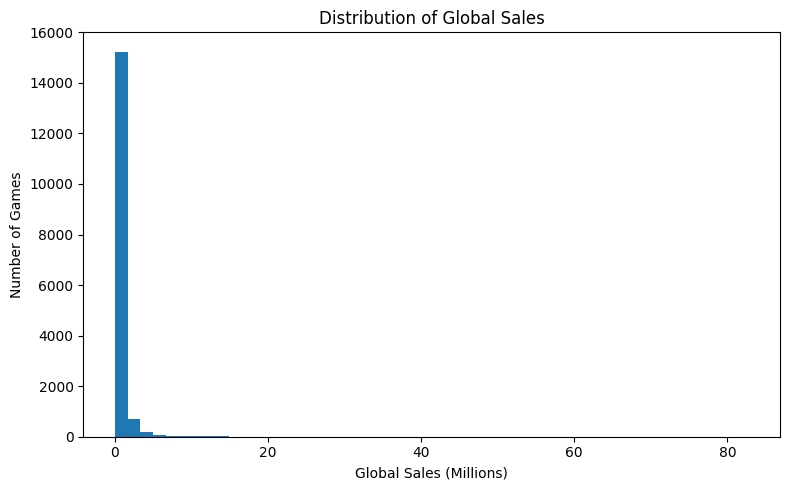

In [52]:
plt.figure(figsize=(8, 5))
plt.hist(df['Global_Sales'], bins=50)
plt.xlabel('Global Sales (Millions)')
plt.ylabel('Number of Games')
plt.title('Distribution of Global Sales')
plt.tight_layout()
plt.show()

The distribution of `Global_Sales` is highly right-skewed. Most games sell relatively low volumes, while a small number of titles achieve very high sales. This imbalance suggests that extreme values may influence model performance.

Such skewness can negatively impact regression models by giving disproportionate influence to high-selling games. To address this, a transformation such as log scaling may be applied to reduce skewness and improve model performance.

#### Figure 2: Number of Games by Genre

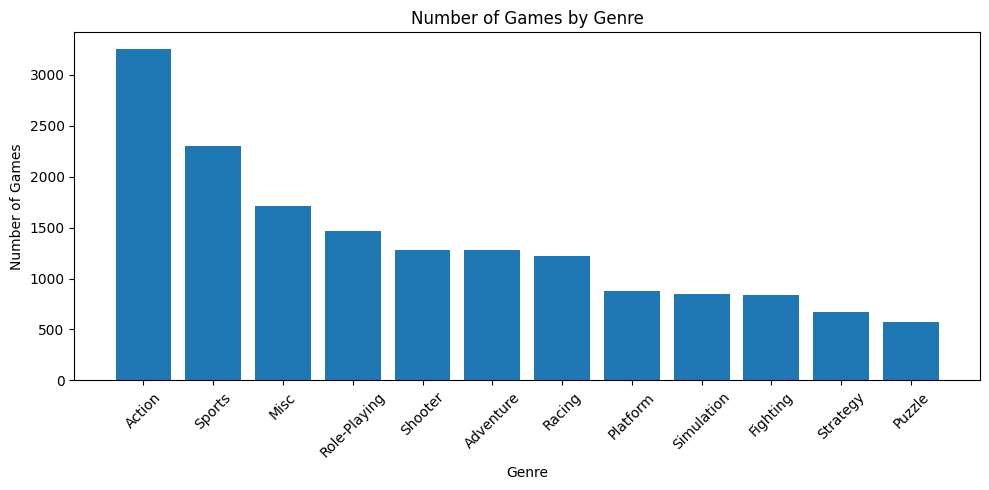

In [53]:
genre_counts = df['Genre'].value_counts()
plt.figure(figsize=(10, 5))
plt.bar(genre_counts.index, genre_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Genre')
plt.ylabel('Number of Games')
plt.title('Number of Games by Genre')
plt.tight_layout()
plt.show()

The genre distribution shows that Action, Sports, and Misc are the most frequent categories in the dataset. This imbalance suggests that the model may be more influenced by these dominant genres, which could impact its ability to generalise to less common genres.

#### Figure 3: Number of Games by Platform

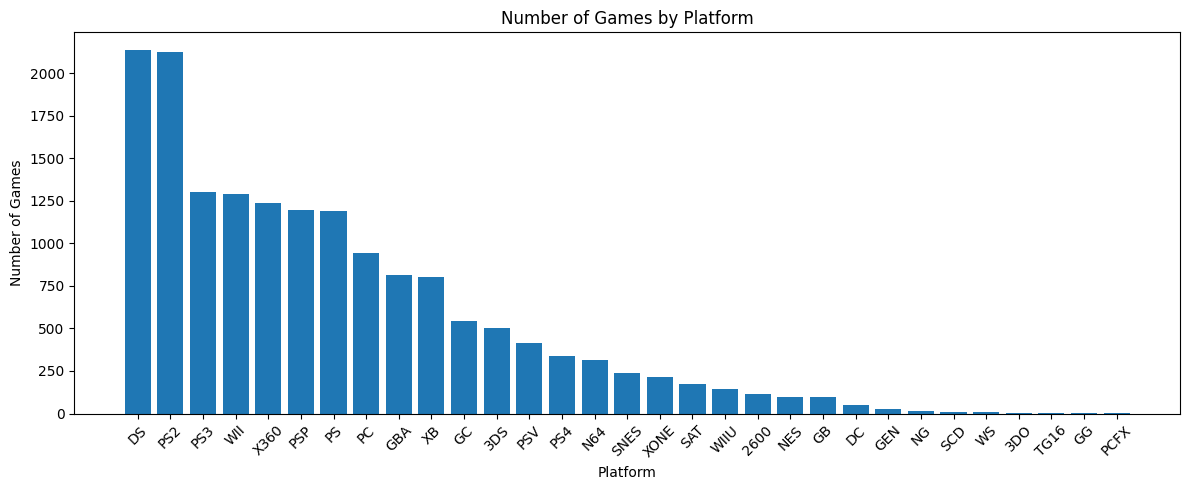

In [54]:
platform_counts = df['Platform'].value_counts()
plt.figure(figsize=(12, 5))
plt.bar(platform_counts.index, platform_counts.values)
plt.xticks(rotation=45)
plt.xlabel('Platform')
plt.ylabel('Number of Games')
plt.title('Number of Games by Platform')
plt.tight_layout()
plt.show()

The platform distribution shows that a small number of platforms, such as DS, PS2, and PS3, have the highest number of game releases, while many other platforms have significantly fewer titles. This strong imbalance means a few dominant platforms account for a large proportion of observations.

This may introduce bias in the model, as it may learn patterns more representative of these dominant platforms. Model predictions for less-represented platforms may be less accurate, which will be considered during evaluation.

### Relationship Analysis

To understand how variables relate to global sales, relationships between regional sales and global sales were examined.

#### Figure 4: NA Sales vs Global Sales

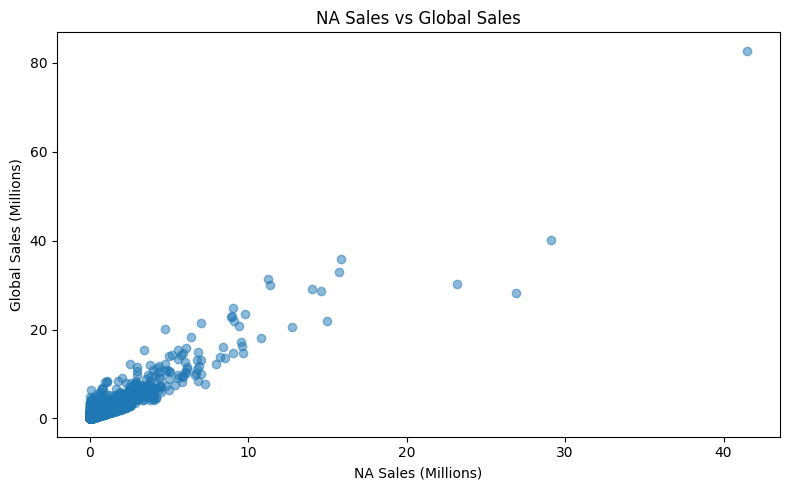

In [55]:
plt.figure(figsize=(8, 5))
plt.scatter(df['NA_Sales'], df['Global_Sales'], alpha=0.5)
plt.xlabel('NA Sales (Millions)')
plt.ylabel('Global Sales (Millions)')
plt.title('NA Sales vs Global Sales')
plt.tight_layout()
plt.show()

The scatter plot shows a strong positive relationship between `NA_Sales` and `Global_Sales`. Most data points follow an upward trend, indicating that NA sales are a key driver of overall sales performance.

While a few high-value outliers are present, the overall pattern remains consistent. This suggests that `NA_Sales` is a strong predictor and should be included as an important feature in the regression model.

#### Figure 5: Correlation Matrix of Sales Variables

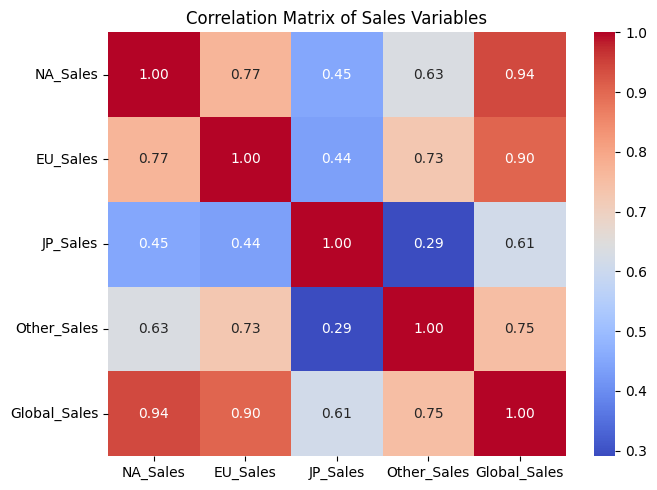

In [56]:
corr = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Sales Variables')
plt.tight_layout()
plt.show()

The correlation heatmap shows strong positive relationships between regional sales and `Global_Sales`. In particular, `NA_Sales` (0.94) and `EU_Sales` (0.90) have the highest correlations with global sales, indicating that these regions are the strongest contributors to overall sales performance.

`Other_Sales` (0.75) also shows a moderate positive relationship, while `JP_Sales` (0.61) has a weaker but still meaningful correlation. Additionally, there is noticeable correlation between NA and EU sales (0.77), suggesting that successful games often perform well across multiple major markets.

These findings indicate that regional sales variables are highly informative. However, using them directly as features to predict `Global_Sales` causes data leakage, since global sales is derived from regional sales — this is addressed in the improved model.

#### Figure 6: Global Sales by Genre (Boxplot)

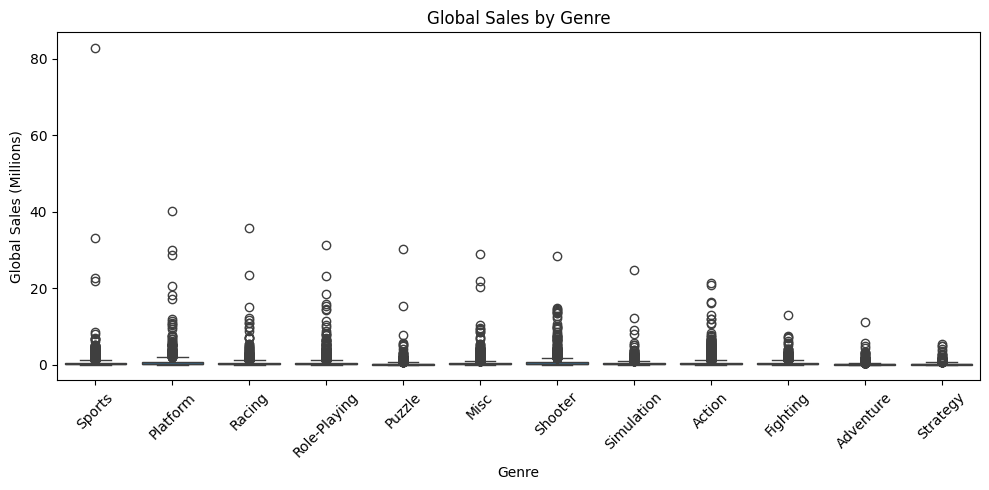

In [57]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Genre', y='Global_Sales', data=df)
plt.xticks(rotation=45)
plt.xlabel('Genre')
plt.ylabel('Global Sales (Millions)')
plt.title('Global Sales by Genre')
plt.tight_layout()
plt.show()

The boxplot shows the distribution of `Global_Sales` across different genres, highlighting differences in median sales and variability. Genres such as Misc, Sports, and Action tend to have higher median sales and a wider spread, indicating greater variability and the potential for high-performing titles.

In contrast, genres such as Strategy and Adventure show lower median sales and a more compact distribution. The presence of multiple outliers across genres indicates that while most games perform modestly, a few achieve exceptionally high sales.

These patterns suggest that genre has a significant impact on sales performance and should be included as a categorical feature in the predictive model.

### EDA Summary

Exploratory data analysis revealed several important patterns that directly guide the modelling approach:

- **Regional sales** (particularly NA and EU) show the strongest relationships with global sales and will be key predictors.
- **Global_Sales is highly right-skewed** — a log transformation may improve model stability.
- **Genre** plays a significant role in sales performance and will be included as a categorical feature.
- **Platform imbalance** may introduce bias; model performance will be evaluated carefully.
- **Strong inter-regional correlations** suggest potential multicollinearity, which will be considered during feature selection.

---
## Stage 6: Baseline Model — Linear Regression

A Linear Regression model is used as the baseline due to its simplicity and interpretability. Regional sales are used as features.

In [58]:
X_base = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
y_base = df['Global_Sales']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42
)

lr = LinearRegression()
lr.fit(X_train_b, y_train_b)
y_pred_lr = lr.predict(X_test_b)

rmse_lr = np.sqrt(mean_squared_error(y_test_b, y_pred_lr))
r2_lr   = r2_score(y_test_b, y_pred_lr)
print(f'RMSE: {rmse_lr:.6f}')
print(f'R²:   {r2_lr:.6f}')

RMSE: 0.005256
R²:   0.999994


The Linear Regression model achieves a near-perfect R² and extremely low RMSE. However, this result is expected because `Global_Sales` is directly calculated as the sum of the regional sales columns used as features. The model is effectively learning an almost exact linear relationship — this is **data leakage**, not genuine predictive power.

These results should be interpreted with caution. The baseline serves as a reference point only.

---
## Stage 7: Improved Model — Tuned Random Forest (No Leakage)

Regional sales features are dropped to eliminate data leakage. The model instead uses platform, genre, publisher, and year — features that would realistically be available before sales are known.

In [59]:
df_model   = df.drop(columns=['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']).dropna()
df_encoded = pd.get_dummies(df_model, columns=['Platform', 'Genre', 'Publisher'], drop_first=True)

X = df_encoded.drop(columns=['Global_Sales', 'Name'])
y = df_encoded['Global_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))
r2_rf   = r2_score(y_test, y_pred)
print(f'RMSE: {rmse_rf:.6f}')
print(f'R²:   {r2_rf:.6f}')

RMSE: 0.855836
R²:   0.828514


The tuned Random Forest model achieves an R² of ~0.83 and an RMSE of ~0.86, which is a more realistic representation of predictive performance without data leakage.

Compared to the baseline Linear Regression (after removing regional sales), the Random Forest performs better by capturing non-linear relationships between platform, genre, publisher, and year. This suggests that the relationship between these variables and global sales is not purely linear.

Tuning hyperparameters (number of trees, max depth, minimum samples) helped the model generalise better and reduce prediction error.

**Final model choice:** The tuned Random Forest is selected as the final model because it provides a better balance between accuracy and generalisation, is more robust to outliers, and avoids data leakage.

---
## Stage 8: Export Predictions

In [60]:
test_meta = df_model.loc[y_test.index, ['Name', 'Platform', 'Genre', 'Year']]
results = pd.DataFrame({
    'Name':      test_meta['Name'].values,
    'Platform':  test_meta['Platform'].values,
    'Genre':     test_meta['Genre'].values,
    'Year':      test_meta['Year'].values,
    'Actual':    y_test.values,
    'Predicted': y_pred.round(3),
})
results.to_csv(PRED_PATH, index=False)
print(f'Exported {len(results):,} rows → {PRED_PATH}')
results.head()

Exported 3,266 rows → model_predictions.csv


,Name,Platform,Genre,Year,Actual,Predicted
0,Looney Tunes: Cartoon Conductor,DS,Misc,2008,0.05,0.050
1,Sonic Jam,SAT,Platform,1997,0.12,0.121
2,The Lord of the Rings: Conquest,PC,Action,2009,0.03,0.030
3,Bigfoot: Collision Course,WII,Racing,2008,0.32,0.320
4,Up,PS3,Action,2009,0.25,0.250


---
## Pipeline Complete

| Output | Description |
|--------|-------------|
| `vgsales.csv` | Raw data (untouched) |
| `vgsales_cleaned.csv` | Cleaned CSV |
| `vgsales.db` | SQLite DB (tables: `games`, `data_dictionary`) |
| `model_predictions.csv` | Actual vs predicted Global Sales for the test set |